In [145]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth, AffinityPropagation
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [5]:
df = pd.read_csv("preprocessed_data.csv")
df.head()

,efsaprodcode2_recoded,Alpha-Tocopherol,Calcium,Copper,Magnesium,"Niacin Equivalents, Total",Phosphorus,Potassium,Riboflavin,Thiamin,...,Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities,"Vitamin K, Total",Zinc,foodLevel1,foodLevel2,foodLevel3,foodLevel4,level1,level2,level3
0,Acidophilus milk,0.085260,4.816819,0.006976,2.533697,0.671486,4.568803,5.039732,0.166724,0.032744,...,0.201579,0.001000,0.356675,0,0,0,0,14,25,146
1,"Acidophilus milk, QUAL Semi-skimmed",0.036332,4.702556,0.044973,2.418462,0.524729,4.447681,4.937552,0.149405,0.027198,...,0.022088,0.000000,0.327246,0,25,0,0,14,25,146
2,"Acidophilus milk, QUAL Skim",0.000000,4.773103,0.005187,2.586689,0.537662,4.552372,5.015386,0.160173,0.034263,...,0.086178,0.000000,0.349650,0,26,0,0,14,25,146
3,Alcoholic sweet sauce,0.623261,3.295837,0.080658,2.079442,0.670902,4.564348,4.189655,0.083422,0.036332,...,0.623261,0.001998,0.537078,1,0,0,0,16,18,47
4,Alcopop and flavoured wine,0.000000,1.648659,0.030529,0.759247,0.000000,1.945910,2.197225,0.000000,0.000000,...,0.000000,0.000000,0.019901,2,0,0,0,1,45,117


In [17]:
nutrient_columns = [
    col for col in df.columns
    if col not in ["efsaprodcode2_recoded", "foodLevel1", "foodLevel2", 
                   "foodLevel3", "foodLevel4", "level1", "level2", "level3"]
]

nutrient_df = df[nutrient_columns]

nutrient_df.columns.tolist()

['Alpha-Tocopherol',
 'Calcium',
 'Copper',
 'Magnesium',
 'Niacin Equivalents, Total',
 'Phosphorus',
 'Potassium',
 'Riboflavin',
 'Thiamin',
 'Total Iron',
 'Total Selenium',
 'Vitamin B-12',
 'Vitamin B-6, Total',
 'Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities',
 'Vitamin K, Total',
 'Zinc']

In [20]:
scaler = StandardScaler()
scaled = scaler.fit_transform(nutrient_df)

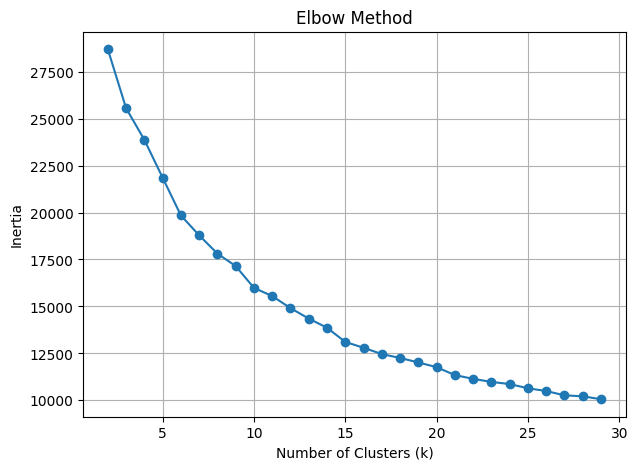

In [151]:
inertia_list = []
K_range = range(2, 30)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [152]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(scaled)

df['kmeans_cluster'] = clusters
df.head()

,efsaprodcode2_recoded,Alpha-Tocopherol,Calcium,Copper,Magnesium,"Niacin Equivalents, Total",Phosphorus,Potassium,Riboflavin,Thiamin,...,level1,level2,level3,kmeans_cluster,hierarchical_cluster,dbscan_cluster,gmm_cluster,spectral_cluster,meanshift_cluster,affinity_cluster
0,Acidophilus milk,0.085260,4.816819,0.006976,2.533697,0.671486,4.568803,5.039732,0.166724,0.032744,...,14,25,146,2,1,0,3,3,0,81
1,"Acidophilus milk, QUAL Semi-skimmed",0.036332,4.702556,0.044973,2.418462,0.524729,4.447681,4.937552,0.149405,0.027198,...,14,25,146,2,1,0,3,3,0,81
2,"Acidophilus milk, QUAL Skim",0.000000,4.773103,0.005187,2.586689,0.537662,4.552372,5.015386,0.160173,0.034263,...,14,25,146,2,1,0,3,3,0,81
3,Alcoholic sweet sauce,0.623261,3.295837,0.080658,2.079442,0.670902,4.564348,4.189655,0.083422,0.036332,...,16,18,47,2,1,-1,3,3,0,23
4,Alcopop and flavoured wine,0.000000,1.648659,0.030529,0.759247,0.000000,1.945910,2.197225,0.000000,0.000000,...,1,45,117,4,2,1,0,0,8,28


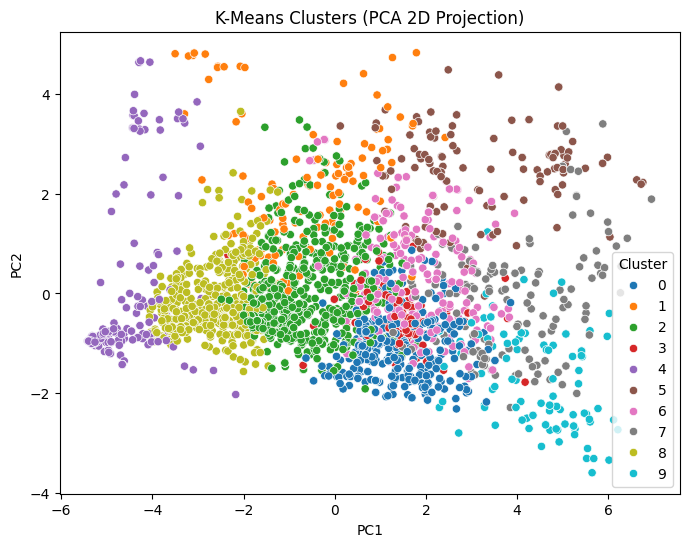

In [153]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df['kmeans_cluster'], palette='tab10')
plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [156]:
# Choose number of clusters
n_clusters = 10

hc = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',
    linkage='ward'
)

hier_clusters = hc.fit_predict(scaled)
df['hierarchical_cluster'] = hier_clusters
df.head()

,efsaprodcode2_recoded,Alpha-Tocopherol,Calcium,Copper,Magnesium,"Niacin Equivalents, Total",Phosphorus,Potassium,Riboflavin,Thiamin,...,level1,level2,level3,kmeans_cluster,hierarchical_cluster,dbscan_cluster,gmm_cluster,spectral_cluster,meanshift_cluster,affinity_cluster
0,Acidophilus milk,0.085260,4.816819,0.006976,2.533697,0.671486,4.568803,5.039732,0.166724,0.032744,...,14,25,146,2,3,0,3,3,0,81
1,"Acidophilus milk, QUAL Semi-skimmed",0.036332,4.702556,0.044973,2.418462,0.524729,4.447681,4.937552,0.149405,0.027198,...,14,25,146,2,3,0,3,3,0,81
2,"Acidophilus milk, QUAL Skim",0.000000,4.773103,0.005187,2.586689,0.537662,4.552372,5.015386,0.160173,0.034263,...,14,25,146,2,3,0,3,3,0,81
3,Alcoholic sweet sauce,0.623261,3.295837,0.080658,2.079442,0.670902,4.564348,4.189655,0.083422,0.036332,...,16,18,47,2,3,-1,3,3,0,23
4,Alcopop and flavoured wine,0.000000,1.648659,0.030529,0.759247,0.000000,1.945910,2.197225,0.000000,0.000000,...,1,45,117,4,2,1,0,0,8,28


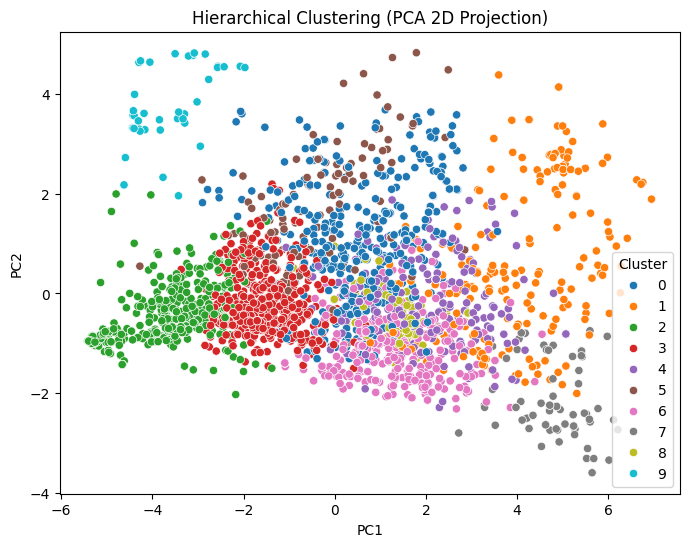

In [157]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1],
                hue=df['hierarchical_cluster'],
                palette='tab10')
plt.title("Hierarchical Clustering (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [58]:
hc = AgglomerativeClustering(
    n_clusters=6,
    metric='euclidean',
    linkage='ward',
    compute_full_tree=True
)

In [175]:
# Core parameters
eps_value = 0.8
min_samples_value = 5

db = DBSCAN(
    eps=eps_value,
    min_samples=min_samples_value,
    metric='euclidean'
)

dbscan_clusters = db.fit_predict(scaled)
df['dbscan_cluster'] = dbscan_clusters
df['dbscan_cluster'].value_counts()

dbscan_cluster
-1     1769
 1      316
 0      102
 3       31
 9       21
 26      16
 2       13
 4       10
 10      10
 17      10
 13      10
 28       9
 31       8
 41       8
 20       7
 15       7
 12       7
 16       7
 7        7
 32       7
 29       6
 34       6
 38       6
 6        6
 25       6
 21       6
 11       6
 18       6
 22       6
 40       5
 5        5
 30       5
 35       5
 19       5
 8        5
 14       5
 33       5
 27       5
 23       5
 24       5
 39       5
 36       5
 37       5
 42       4
Name: count, dtype: int64

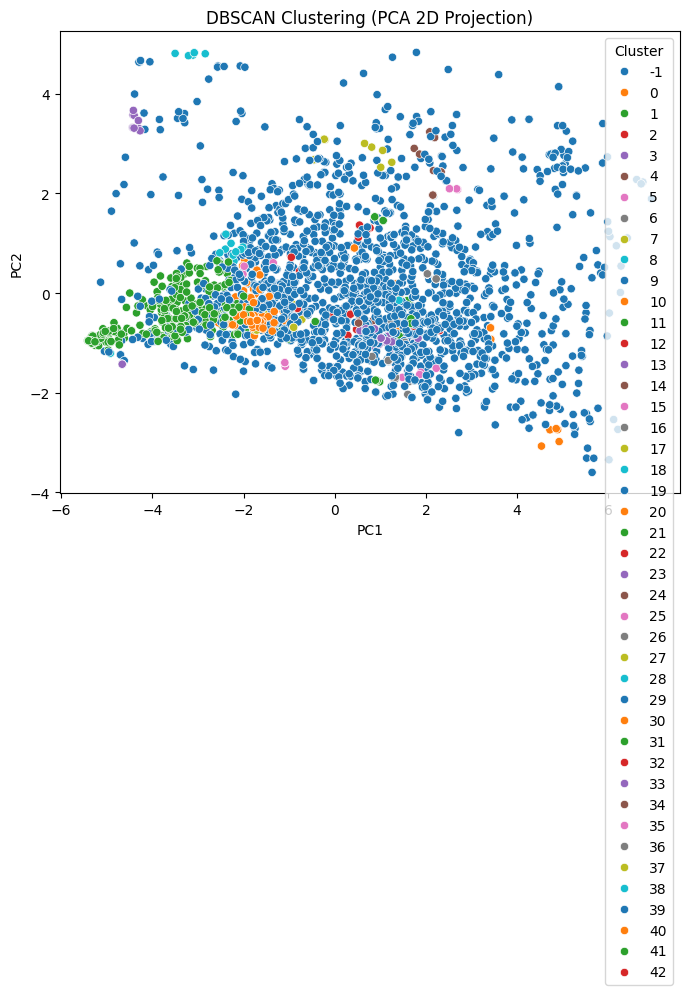

In [176]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1],
                hue=df['dbscan_cluster'], palette='tab10')
plt.title("DBSCAN Clustering (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [62]:
for e in [0.2, 0.5, 0.8, 1.0]:
    print(e, DBSCAN(eps=e, min_samples=5).fit_predict(scaled).max())

0.2 15
0.5 27
0.8 42
1.0 45


In [158]:
# Choose components (similar to k in k-means)
n_components = 10

gmm = GaussianMixture(
    n_components=n_components,
    covariance_type='spherical',
    n_init=10,
    random_state=42
)

gmm_clusters = gmm.fit_predict(scaled)
df['gmm_cluster'] = gmm_clusters
df.head()

,efsaprodcode2_recoded,Alpha-Tocopherol,Calcium,Copper,Magnesium,"Niacin Equivalents, Total",Phosphorus,Potassium,Riboflavin,Thiamin,...,level1,level2,level3,kmeans_cluster,hierarchical_cluster,dbscan_cluster,gmm_cluster,spectral_cluster,meanshift_cluster,affinity_cluster
0,Acidophilus milk,0.085260,4.816819,0.006976,2.533697,0.671486,4.568803,5.039732,0.166724,0.032744,...,14,25,146,2,3,0,3,3,0,81
1,"Acidophilus milk, QUAL Semi-skimmed",0.036332,4.702556,0.044973,2.418462,0.524729,4.447681,4.937552,0.149405,0.027198,...,14,25,146,2,3,0,3,3,0,81
2,"Acidophilus milk, QUAL Skim",0.000000,4.773103,0.005187,2.586689,0.537662,4.552372,5.015386,0.160173,0.034263,...,14,25,146,2,3,0,3,3,0,81
3,Alcoholic sweet sauce,0.623261,3.295837,0.080658,2.079442,0.670902,4.564348,4.189655,0.083422,0.036332,...,16,18,47,2,3,-1,3,3,0,23
4,Alcopop and flavoured wine,0.000000,1.648659,0.030529,0.759247,0.000000,1.945910,2.197225,0.000000,0.000000,...,1,45,117,4,2,1,2,0,8,28


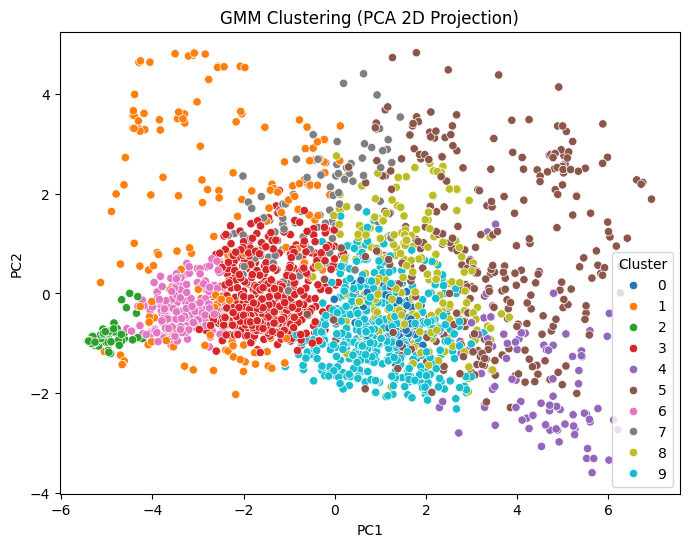

In [159]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1],
                hue=df['gmm_cluster'],
                palette='tab10')
plt.title("GMM Clustering (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [66]:
gmm = GaussianMixture(
    n_components=6,
    covariance_type='diag',
    n_init=20,
    reg_covar=1e-6,
    random_state=42
)

In [ ]:
bandwidth = estimate_bandwidth(scaled, quantile=0.2, n_samples=500)
print("Estimated bandwidth:", bandwidth)

meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels = meanshift.fit_predict(scaled)

df['meanshift_cluster'] = ms_labels
df.head()

Estimated bandwidth: 3.7970327951138008


,efsaprodcode2_recoded,Alpha-Tocopherol,Calcium,Copper,Magnesium,"Niacin Equivalents, Total",Phosphorus,Potassium,Riboflavin,Thiamin,...,level1,level2,level3,kmeans_cluster,hierarchical_cluster,dbscan_cluster,gmm_cluster,spectral_cluster,meanshift_cluster,affinity_cluster
0,Acidophilus milk,0.085260,4.816819,0.006976,2.533697,0.671486,4.568803,5.039732,0.166724,0.032744,...,14,25,146,2,1,0,3,3,0,81
1,"Acidophilus milk, QUAL Semi-skimmed",0.036332,4.702556,0.044973,2.418462,0.524729,4.447681,4.937552,0.149405,0.027198,...,14,25,146,2,1,0,3,3,0,81
2,"Acidophilus milk, QUAL Skim",0.000000,4.773103,0.005187,2.586689,0.537662,4.552372,5.015386,0.160173,0.034263,...,14,25,146,2,1,0,3,3,0,81
3,Alcoholic sweet sauce,0.623261,3.295837,0.080658,2.079442,0.670902,4.564348,4.189655,0.083422,0.036332,...,16,18,47,2,1,-1,3,3,0,23
4,Alcopop and flavoured wine,0.000000,1.648659,0.030529,0.759247,0.000000,1.945910,2.197225,0.000000,0.000000,...,1,45,117,4,2,1,0,0,8,28


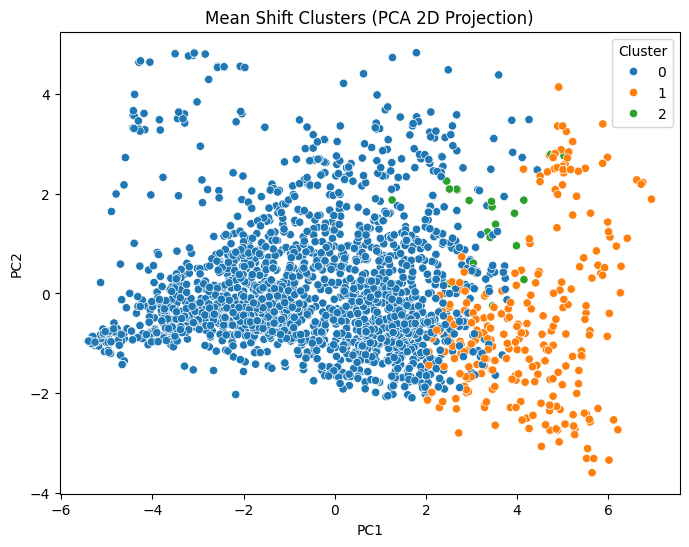

In [147]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_result[:,0],
    y=pca_result[:,1],
    hue=df['meanshift_cluster'],
    palette='tab10'
)
plt.title("Mean Shift Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [168]:
aff = AffinityPropagation(damping=0.9, random_state=42)
aff_labels = aff.fit_predict(scaled)

df['affinity_cluster'] = aff_labels
df.head()

,efsaprodcode2_recoded,Alpha-Tocopherol,Calcium,Copper,Magnesium,"Niacin Equivalents, Total",Phosphorus,Potassium,Riboflavin,Thiamin,...,level1,level2,level3,kmeans_cluster,hierarchical_cluster,dbscan_cluster,gmm_cluster,spectral_cluster,meanshift_cluster,affinity_cluster
0,Acidophilus milk,0.085260,4.816819,0.006976,2.533697,0.671486,4.568803,5.039732,0.166724,0.032744,...,14,25,146,2,3,0,3,3,0,81
1,"Acidophilus milk, QUAL Semi-skimmed",0.036332,4.702556,0.044973,2.418462,0.524729,4.447681,4.937552,0.149405,0.027198,...,14,25,146,2,3,0,3,3,0,81
2,"Acidophilus milk, QUAL Skim",0.000000,4.773103,0.005187,2.586689,0.537662,4.552372,5.015386,0.160173,0.034263,...,14,25,146,2,3,0,3,3,0,81
3,Alcoholic sweet sauce,0.623261,3.295837,0.080658,2.079442,0.670902,4.564348,4.189655,0.083422,0.036332,...,16,18,47,2,3,-1,3,3,0,23
4,Alcopop and flavoured wine,0.000000,1.648659,0.030529,0.759247,0.000000,1.945910,2.197225,0.000000,0.000000,...,1,45,117,4,2,1,2,0,8,28


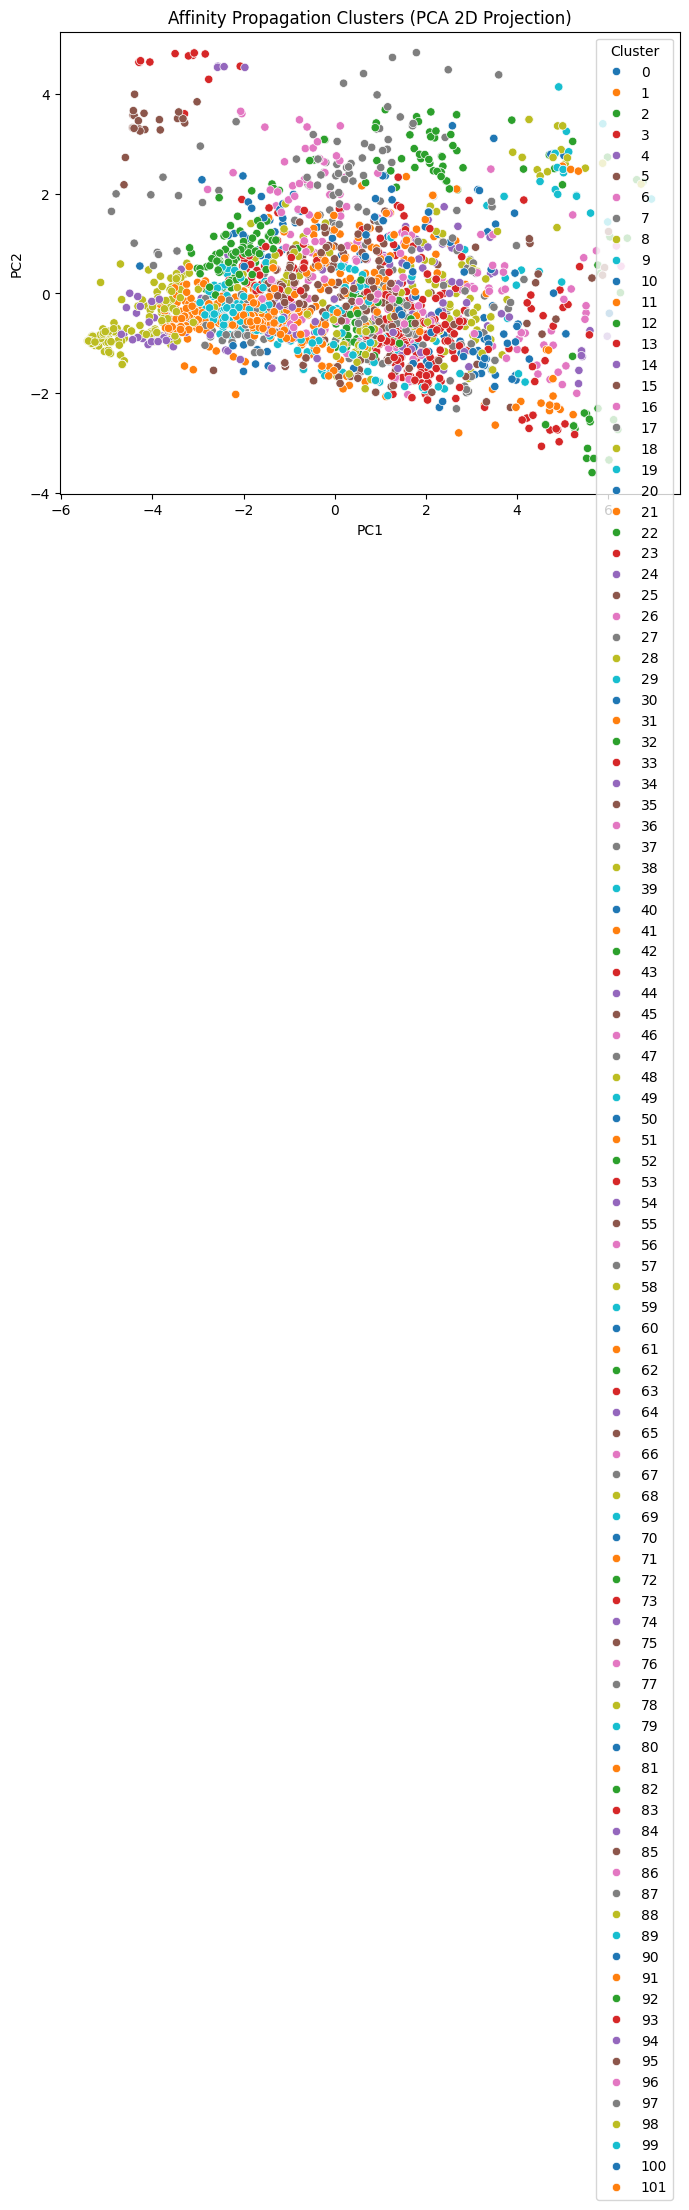

In [169]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_result[:,0],
    y=pca_result[:,1],
    hue=df['affinity_cluster'],
    palette='tab10'
)
plt.title("Affinity Propagation Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()